# Model Training & Comparison

**Objectives:**
- Train all three models with cross-validation
- Compare ROC-AUC, F1, Precision, Recall
- Plot ROC curves and Precision-Recall curves
- Select the best model for explainability notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('./models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE  = 42

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

X_train = pd.read_csv(PROCESSED_DIR / 'X_train_selected.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_selected.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Default rate — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

X_train: (25343, 20) | X_test: (6336, 20)
Default rate — train: 0.215 | test: 0.215


## 1. Define Models
All models use class_weight / scale_pos_weight to handle the 78/22 imbalance 
without resampling - this keeps the training set realistic.

In [3]:
# Imbalance ratio for XGBoost scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
imbalance_ratio = neg / pos
print(f'Imbalance ratio (neg/pos): {imbalance_ratio:.2f}')

MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=imbalance_ratio,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

Imbalance ratio (neg/pos): 3.64


## 2. Cross-Validation
5-fold stratified CV on the training set. We report ROC-AUC and F1 
(macro) - both matter given class imbalance.

In [6]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['roc_auc', 'f1', 'precision', 'recall']

cv_results = {}

for name, model in MODELS.items():
    scores = cross_validate(model, X_train, y_train,
                            cv=CV, scoring=SCORING, n_jobs=-1)
    cv_results[name] = {
        'ROC-AUC' : scores['test_roc_auc'].mean(),
        'ROC-AUC std': scores['test_roc_auc'].std(),
        'F1'      : scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall'  : scores['test_recall'].mean(),
    }
    print(f"{name}: AUC={cv_results[name]['ROC-AUC']:.4f} ± "
          f"{cv_results[name]['ROC-AUC std']:.4f} | "
          f"F1={cv_results[name]['F1']:.4f}")

cv_df = pd.DataFrame(cv_results).T
cv_df

Logistic Regression: AUC=0.8665 ± 0.0077 | F1=0.6277
XGBoost: AUC=0.9446 ± 0.0048 | F1=0.8036
LightGBM: AUC=0.9450 ± 0.0048 | F1=0.8046


,ROC-AUC,ROC-AUC std,F1,Precision,Recall
Logistic Regression,0.866495,0.007740,0.627742,0.525163,0.780403
XGBoost,0.944567,0.004848,0.803626,0.824573,0.783883
LightGBM,0.944963,0.004791,0.804554,0.824072,0.786264


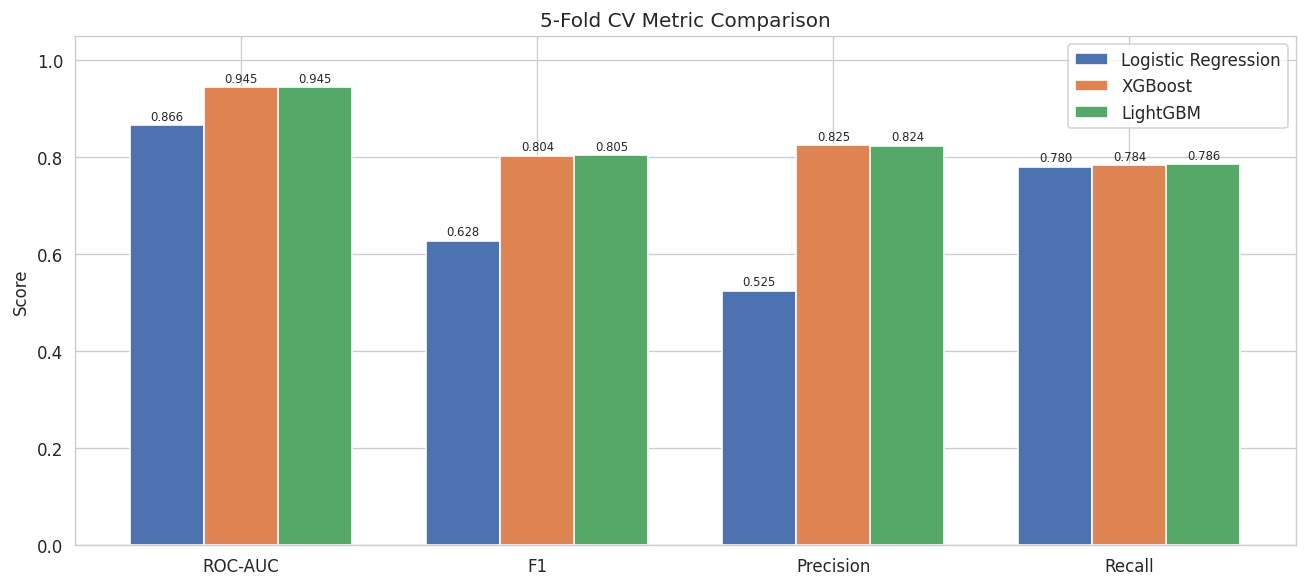

In [7]:
metrics = ['ROC-AUC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, color) in enumerate(zip(MODELS.keys(), colors)):
    vals = [cv_results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title('5-Fold CV Metric Comparison')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Train Final Models
After CV confirms stability, we train each model on the full X_train 
and evaluate on the held-out X_test.

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Fit model and return test set predictions and probabilities.

    Args:
        model: Sklearn-compatible classifier.
        X_tr, y_tr: Training features and labels.
        X_te, y_te: Test features and labels.
        name: Model name string for logging.

    Returns:
        Tuple of (y_pred, y_proba).
    """
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    print(f'\n{"="*40}')
    print(f'  {name}')
    print(f'{"="*40}')
    print(classification_report(y_te, y_pred, target_names=['No Default', 'Default']))
    print(f'ROC-AUC: {roc_auc_score(y_te, y_proba):.4f}')
    return y_pred, y_proba

fitted_models   = {}
test_preds      = {}
test_probas     = {}

for name, model in MODELS.items():
    y_pred, y_proba = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    fitted_models[name] = model
    test_preds[name]    = y_pred
    test_probas[name]   = y_proba


  Logistic Regression
              precision    recall  f1-score   support

  No Default       0.93      0.80      0.86      4971
     Default       0.52      0.79      0.63      1365

    accuracy                           0.80      6336
   macro avg       0.73      0.80      0.75      6336
weighted avg       0.85      0.80      0.81      6336

ROC-AUC: 0.8709

  XGBoost
              precision    recall  f1-score   support

  No Default       0.95      0.96      0.95      4971
     Default       0.85      0.80      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.90      0.88      0.89      6336
weighted avg       0.92      0.93      0.92      6336

ROC-AUC: 0.9500

  LightGBM
              precision    recall  f1-score   support

  No Default       0.95      0.96      0.95      4971
     Default       0.84      0.80      0.82      1365

    accuracy                           0.92      6336
   macro avg       0.89      0.88      0.89      6

## 4. ROC Curves

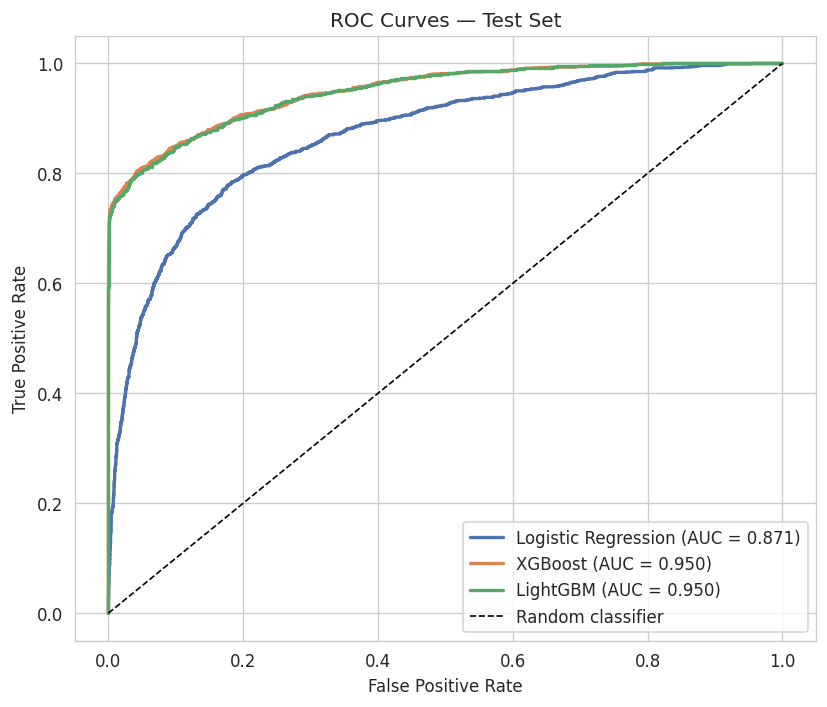

In [9]:
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), color in zip(test_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Precision-Recall Curves
ROC-AUC can be optimistic on imbalanced datasets. 
Precision-Recall curves provide a clearer picture of performance on the minority class.

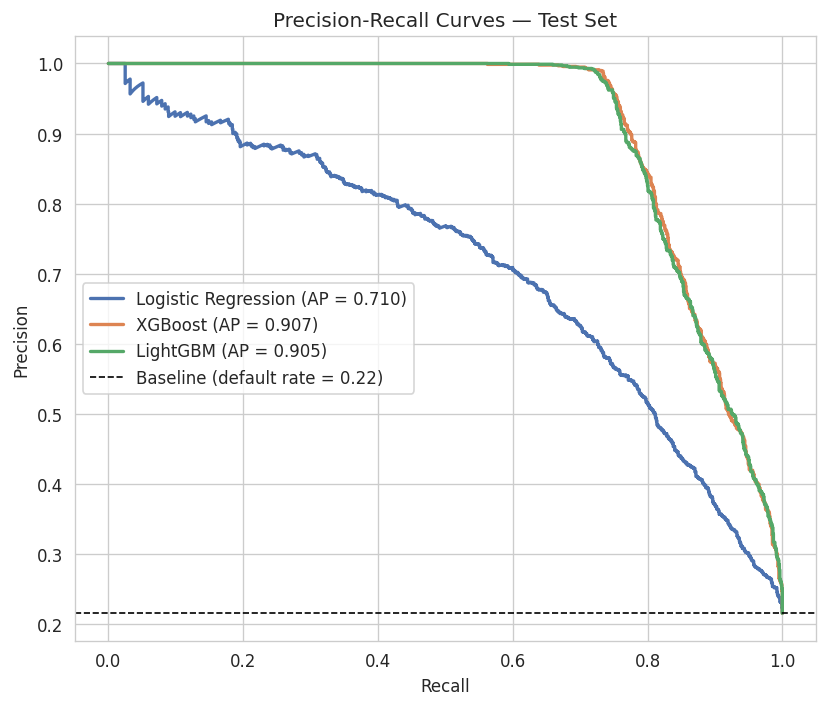

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for (name, proba), color in zip(test_probas.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', color=color, lw=2)

baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', lw=1,
           label=f'Baseline (default rate = {baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Confusion Matrices

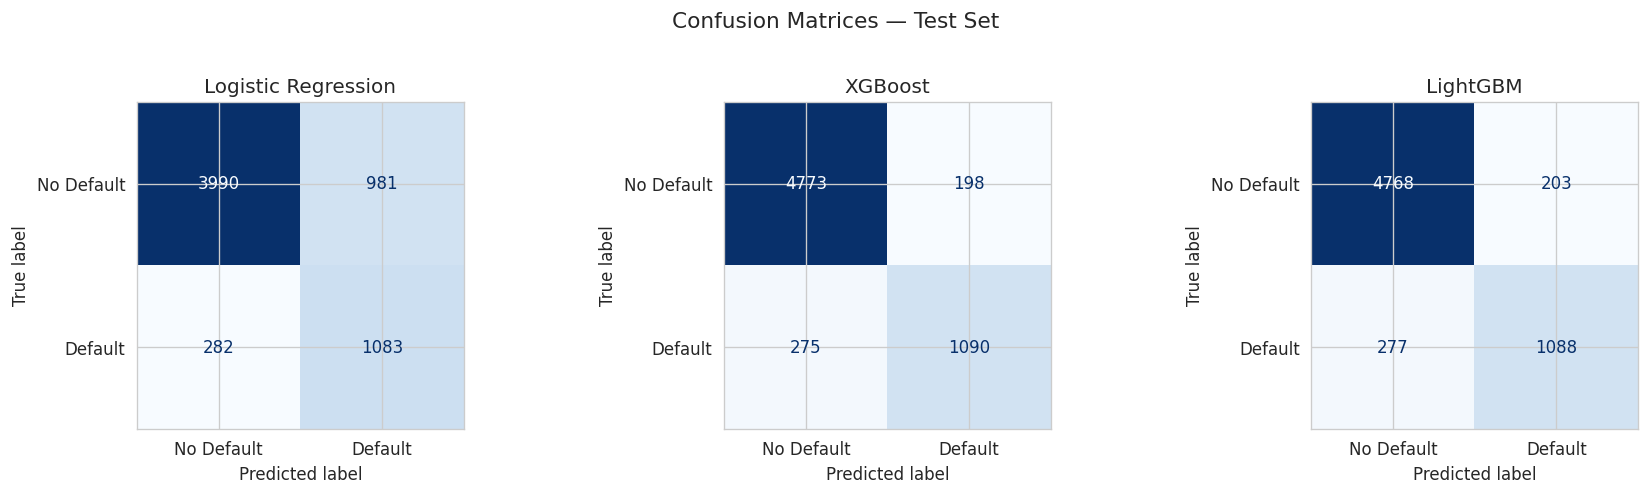

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices — Test Set', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Final Comparison Table

In [12]:
summary = pd.DataFrame({
    name: {
        'ROC-AUC'  : roc_auc_score(y_test, test_probas[name]),
        'Avg Prec' : average_precision_score(y_test, test_probas[name]),
        'F1'       : f1_score(y_test, test_preds[name]),
        'Precision': precision_score(y_test, test_preds[name]),
        'Recall'   : recall_score(y_test, test_preds[name]),
    }
    for name in MODELS
}).T.round(4)

summary

,ROC-AUC,Avg Prec,F1,Precision,Recall
Logistic Regression,0.8709,0.7103,0.6317,0.5247,0.7934
XGBoost,0.9500,0.9065,0.8217,0.8463,0.7985
LightGBM,0.9497,0.9049,0.8193,0.8428,0.7971


In [13]:
# Identify best model by ROC-AUC
best_name  = summary['ROC-AUC'].idxmax()
best_model = fitted_models[best_name]

joblib.dump(best_model, MODELS_DIR / 'best_model.pkl')
print(f'Best model: {best_name}')
print(f'Saved to models/best_model.pkl')

Best model: XGBoost
Saved to models/best_model.pkl


## 8. Summary & Model Selection

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Interpretable, fast, good baseline | Assumes linearity; weaker on complex patterns |
| XGBoost | Strong performance, handles non-linearity | Slower to train; needs tuning |
| LightGBM | Fastest to train; often matches XGBoost | Slightly less stable on small data |

**Selected model for explainability:** The best ROC-AUC model is XGBoost.